
Extrayendo características HOG para TRASHNET (entrenamiento)...
TRASHNET cargado en 81.48 segundos. Total imágenes: 2499

Extrayendo características HOG para TACO (pruebas)...
TACO cargado en 150.90 segundos. Total imágenes: 4374

Entrenando SVM con TRASHNET...

=== REPORTE DE CLASIFICACIÓN (S2 — Train TrashNet / Test TACO) ===
              precision    recall  f1-score   support

   cardboard       0.06      0.63      0.11       232
       glass       0.09      0.26      0.13       247
       metal       0.12      0.23      0.16       517
       paper       0.07      0.04      0.05       218
     plastic       0.44      0.03      0.06      1907
       trash       0.14      0.00      0.00      1253

    accuracy                           0.09      4374
   macro avg       0.15      0.20      0.09      4374
weighted avg       0.26      0.09      0.06      4374



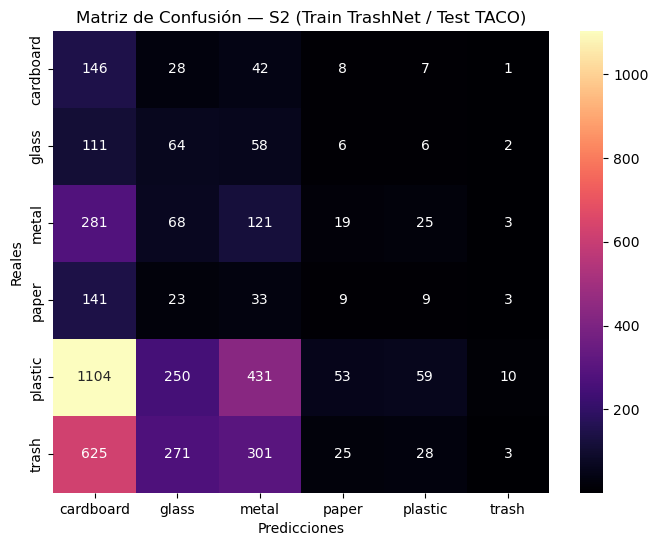

In [1]:
# ================================
# ESCENARIO S2 — TRAIN TRASHNET / TEST TACO
# ================================
import os, time, cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Rutas de los datasets
train_dir = "../../data_preprocessed/HOG_SVM/TrashNet"
test_dir = "../../data_preprocessed/HOG_SVM/TACO"

# =============================================
# EXTRACCIÓN HOG - ENTRENAMIENTO (TrashNet)
# =============================================
print("\nExtrayendo características HOG para TRASHNET (entrenamiento)...")

X_train, y_train = [], []
inicio = time.time()

for clase in sorted(os.listdir(train_dir)):
    clase_path = os.path.join(train_dir, clase)
    if not os.path.isdir(clase_path):
        continue

    for img_name in os.listdir(clase_path):
        img_path = os.path.join(clase_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (128, 128))
        features, _ = hog(img, orientations=9, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')
        X_train.append(features)
        y_train.append(clase)

fin = time.time()
print(f"TRASHNET cargado en {fin - inicio:.2f} segundos. Total imágenes: {len(X_train)}")

# =============================================
# EXTRACCIÓN HOG - PRUEBAS (TACO)
# =============================================
print("\nExtrayendo características HOG para TACO (pruebas)...")

X_test, y_test = [], []
inicio = time.time()

for clase in sorted(os.listdir(test_dir)):
    clase_path = os.path.join(test_dir, clase)
    if not os.path.isdir(clase_path):
        continue

    for img_name in os.listdir(clase_path):
        img_path = os.path.join(clase_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (128, 128))
        features, _ = hog(img, orientations=9, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')
        X_test.append(features)
        y_test.append(clase)

fin = time.time()
print(f"TACO cargado en {fin - inicio:.2f} segundos. Total imágenes: {len(X_test)}")


# =============================================
# ENTRENAMIENTO SVM
# =============================================
print("\nEntrenando SVM con TRASHNET...")

svm_s2 = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
svm_s2.fit(X_train, y_train)

# =============================================
# EVALUACIÓN
# =============================================
print("\n=== REPORTE DE CLASIFICACIÓN (S2 — Train TrashNet / Test TACO) ===")
y_pred = svm_s2.predict(X_test)
print(classification_report(y_test, y_pred))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', 
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicciones")
plt.ylabel("Reales")
plt.title("Matriz de Confusión — S2 (Train TrashNet / Test TACO)")
plt.show()



Extrayendo características HOG para TACO (entrenamiento)...
TACO cargado en 166.26 segundos. Total imágenes: 4374

Extrayendo características HOG para TRASHNET (pruebas)...
TRASHNET cargado en 73.06 segundos. Total imágenes: 2499

Entrenando SVM con TACO...

=== REPORTE DE CLASIFICACIÓN (S3 — Train TACO / Test TrashNet) ===
              precision    recall  f1-score   support

   cardboard       0.07      0.06      0.06       401
       glass       0.14      0.03      0.05       501
       metal       0.22      0.28      0.25       407
       paper       0.28      0.12      0.17       575
     plastic       0.22      0.34      0.27       478
       trash       0.06      0.23      0.09       137

    accuracy                           0.17      2499
   macro avg       0.16      0.18      0.15      2499
weighted avg       0.19      0.17      0.15      2499



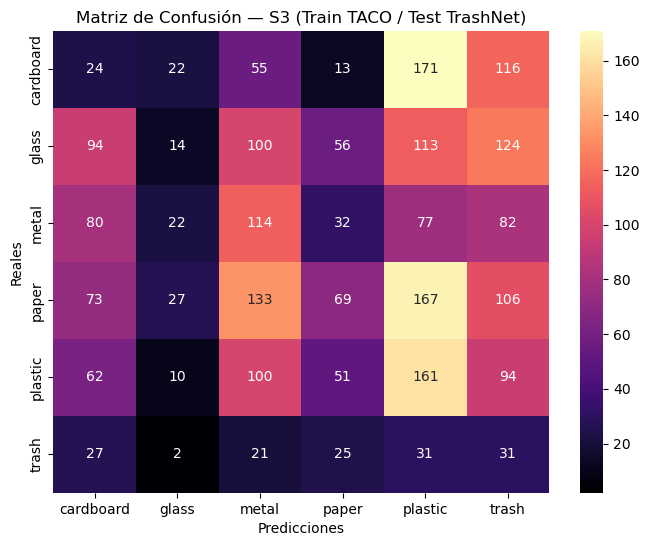

In [4]:
# ================================
# ESCENARIO S3 — TRAIN TACO / TEST TRASHNET
# ================================
import os, time, cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Rutas de los datasets
train_dir = "../../data_preprocessed/HOG_SVM/TACO"
test_dir = "../../data_preprocessed/HOG_SVM/TrashNet"

# =============================================
# EXTRACCIÓN HOG - ENTRENAMIENTO (TACO)
# =============================================
print("\nExtrayendo características HOG para TACO (entrenamiento)...")

X_train, y_train = [], []
inicio = time.time()

for clase in sorted(os.listdir(train_dir)):
    clase_path = os.path.join(train_dir, clase)
    if not os.path.isdir(clase_path):
        continue

    for img_name in os.listdir(clase_path):
        img_path = os.path.join(clase_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (128, 128))
        features, _ = hog(img, orientations=9, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')
        X_train.append(features)
        y_train.append(clase)

fin = time.time()
print(f"TACO cargado en {fin - inicio:.2f} segundos. Total imágenes: {len(X_train)}")

# =============================================
# EXTRACCIÓN HOG - PRUEBAS (TrashNet)
# =============================================
print("\nExtrayendo características HOG para TRASHNET (pruebas)...")

X_test, y_test = [], []
inicio = time.time()

for clase in sorted(os.listdir(test_dir)):
    clase_path = os.path.join(test_dir, clase)
    if not os.path.isdir(clase_path):
        continue

    for img_name in os.listdir(clase_path):
        img_path = os.path.join(clase_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (128, 128))
        features, _ = hog(img, orientations=9, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')
        X_test.append(features)
        y_test.append(clase)

fin = time.time()
print(f"TRASHNET cargado en {fin - inicio:.2f} segundos. Total imágenes: {len(X_test)}")


# =============================================
# ENTRENAMIENTO SVM
# =============================================
print("\nEntrenando SVM con TACO...")

svm_s3 = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
svm_s3.fit(X_train, y_train)

# =============================================
# EVALUACIÓN
# =============================================
print("\n=== REPORTE DE CLASIFICACIÓN (S3 — Train TACO / Test TrashNet) ===")
y_pred = svm_s3.predict(X_test)
print(classification_report(y_test, y_pred))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', 
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicciones")
plt.ylabel("Reales")
plt.title("Matriz de Confusión — S3 (Train TACO / Test TrashNet)")
plt.show()
